# Day 4 — Activations, Gradients, BatchNorm (makemore Part 3, 1h55m)
Lecture names used (n_embd, n_hidden, block_size, vocab_size). Init fixes + BatchNorm + Linear/BatchNorm1d/Tanh classes = my exercises. Starting network is deliberately pre-fix.

In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
# BOILERPLATE: data + maps + split
words = open('names.txt', 'r').read().splitlines()
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
vocab_size = len(itos)

block_size = 3

def build_dataset(word_list):
    X, Y = [], []
    for w in word_list:
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]
    return torch.tensor(X), torch.tensor(Y)

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))
Xtr,  Ytr  = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte,  Yte  = build_dataset(words[n2:])
print(Xtr.shape, Xdev.shape, Xte.shape)

torch.Size([182625, 3]) torch.Size([22655, 3]) torch.Size([22866, 3])


In [3]:
# starting network — NAIVE init (the video's fixes are my exercise)
n_embd = 10
n_hidden = 200

g = torch.Generator().manual_seed(2147483647)
C  = torch.randn((vocab_size, n_embd),            generator=g)
W1 = torch.randn((n_embd * block_size, n_hidden), generator=g)
b1 = torch.randn(n_hidden,                        generator=g)
W2 = torch.randn((n_hidden, vocab_size),          generator=g)
b2 = torch.randn(vocab_size,                      generator=g)

parameters = [C, W1, b1, W2, b2]
print(sum(p.nelement() for p in parameters))
for p in parameters:
    p.requires_grad = True

11897


In [4]:
# BOILERPLATE: optimization loop (use small max_steps during the surgery phase)
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):

    # minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
    Xb, Yb = Xtr[ix], Ytr[ix]

    # forward pass
    emb = C[Xb]
    embcat = emb.view(emb.shape[0], -1)
    hpreact = embcat @ W1 + b1
    h = torch.tanh(hpreact)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Yb)

    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    lr = 0.1 if i < 100000 else 0.01
    for p in parameters:
        p.data += -lr * p.grad

    # track stats
    if i % 10000 == 0:
        print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())

      0/ 200000: 27.8817
  10000/ 200000: 2.8138
  20000/ 200000: 2.5218
  30000/ 200000: 2.7874
  40000/ 200000: 2.0334
  50000/ 200000: 2.6237
  60000/ 200000: 2.3289
  70000/ 200000: 2.0826
  80000/ 200000: 2.2784
  90000/ 200000: 2.2252
 100000/ 200000: 2.0428
 110000/ 200000: 2.3121
 120000/ 200000: 2.0570
 130000/ 200000: 2.4546
 140000/ 200000: 2.2233
 150000/ 200000: 2.1551
 160000/ 200000: 2.0597
 170000/ 200000: 1.7981
 180000/ 200000: 2.0194
 190000/ 200000: 1.7459


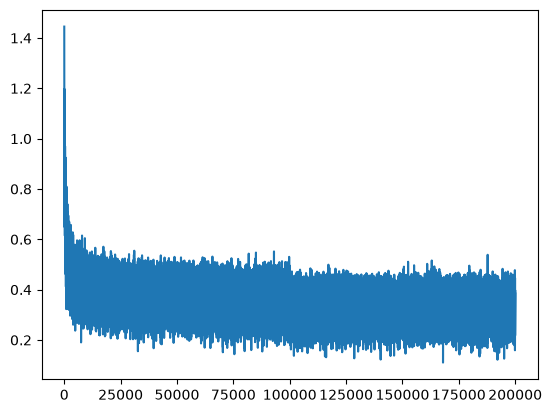

In [5]:
plt.plot(lossi)

In [6]:
@torch.no_grad()
def split_loss(split):
    x, y = {
        'train': (Xtr, Ytr),
        'dev':   (Xdev, Ydev),
        'test':  (Xte, Yte),
    }[split]
    emb = C[x]
    embcat = emb.view(emb.shape[0], -1)
    h = torch.tanh(embcat @ W1 + b1)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, y)
    print(split, loss.item())

split_loss('train')
split_loss('dev')

train 2.1267659664154053
dev 2.1697638034820557


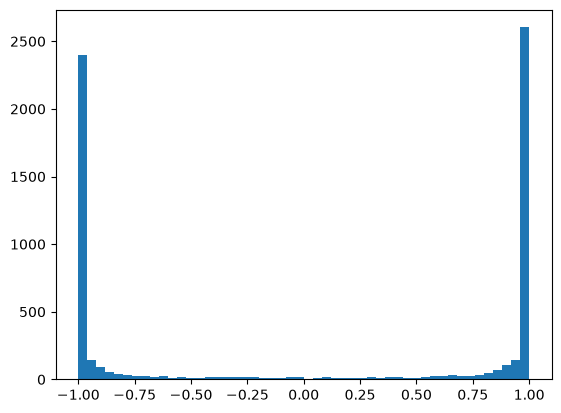

In [7]:
# BOILERPLATE (segment viz, from the lecture): distribution of h — where do activations live?
plt.hist(h.view(-1).tolist(), 50);

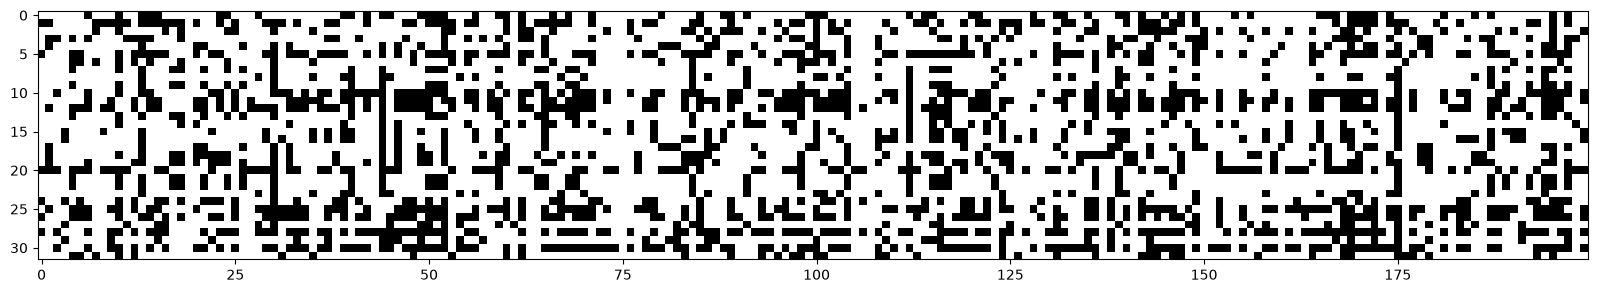

In [8]:
# BOILERPLATE (segment viz, from the lecture): saturation map — white = |h| > 0.99 (dead-ish)
plt.figure(figsize=(20, 10))
plt.imshow(h.abs() > 0.99, cmap='gray', interpolation='nearest')

## Observations — NAIVE init, full 200k run

- **First loss: 27.8817** (lecture gets the same) vs the honest "know-nothing" 3.29 → the net starts ~confidently wrong, exactly the 21.9 disease from my MLP notebook, worse here.
- **Loss curve = hockey stick**: the first chunk of training is spent just squashing the crazy init down to sanity — wasted steps, not learning.
- **Final: train 2.1268 / dev 2.1698** — it still converges fine! 200k steps on a small net can dig itself out of bad init. So the fixes buy SPEED (no wasted phase) and stability, not survival — on THIS shallow net. Deeper nets wouldn't recover (r^L explosion).
- **h histogram: two towers at ±1** — most activations saturated.
- **Saturation map: lots of white** — many (unit, example) pairs in the dead zone, gradient (1−t²)≈0.

Next: the surgery (W2·0.01, b2·0, W1 Kaiming (5/3)/√30, b1 tiny) → expect first loss ≈3.3, hump histogram, black map, and same-or-better final loss in FEWER effective steps.